In [1]:
from pytools.vtk_io import readVTK
import matplotlib.pyplot as plt
import numpy as np

In [2]:
V0=readVTK("data.0000.vtk")

ny = np.shape(V0.data['RHO'])[1]
r = V0.x
phi = V0.y

omega_k = np.sqrt(1/r**3)

omega_k = np.tile(omega_k, (ny, 1))

In [3]:
T0 = V0.data['PRS'][:,:,0]/V0.data['RHO'][:,:,0]
print("min(PRS(t=0))=", np.min(V0.data['PRS'][:,:,0]))
print("min(RHO(t=0))=",np.min(V0.data['RHO'][:,:,0]))
print("min(Temp(t=0))=",np.min(T0))

min(PRS(t=0))= 9.4571064e-08
min(RHO(t=0))= 0.00015861672
min(Temp(t=0))= 0.0005954775


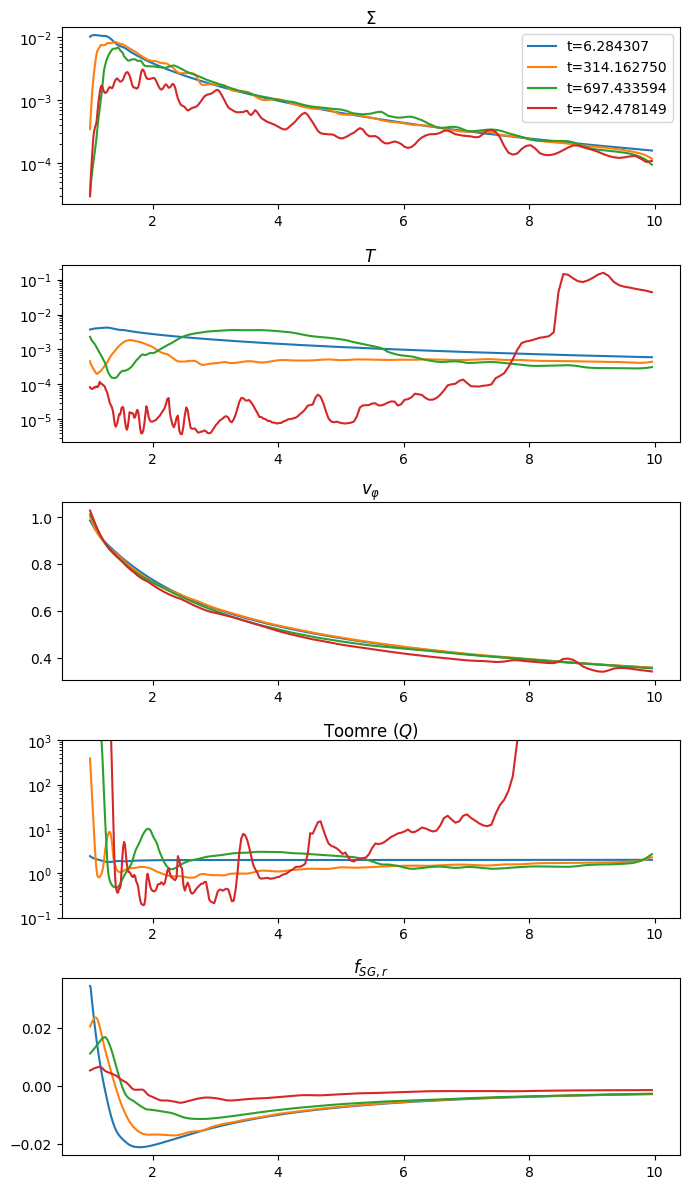

In [5]:
fig, ax      = plt.subplots(5,1, figsize=(7,12))

title = [r"$\Sigma$", r"$T$",r"$v_{\varphi}$", r"Toomre $(Q)$", r"$f_{SG,r}$"]

for name in ["data.0000.vtk", "data.0050.vtk", 
             "data.0111.vtk", "data.0150.vtk"]: 
             #"data.0113.vtk", "data.0114.vtk",
             #"data.0076.vtk", "data.0082.vtk",
             #"data.0306.vtk"]:
    V = readVTK(name)

    rho_mean = np.mean(V.data['RHO'], axis=(1))
    VX2_mean = np.mean(V.data['VX2'], axis=(1))
    T_mean = np.mean(V.data['PRS']/V.data['RHO'], axis=(1))
    forceSGx_mean = np.mean(V.data['forceSGx'], axis=(1))
    toomre_mean = np.mean(V.data['toomre'], axis=(1))

    label = "t=%f"%V.t[0]
    
    ax[0].plot(r, rho_mean, label=label)
    ax[1].plot(r, T_mean[:,0])
    ax[2].plot(r, VX2_mean)
    ax[3].plot(r, toomre_mean)
    ax[4].plot(r, forceSGx_mean)




for n in range(0,5):
    ax[n].set_title(title[n], pad=0)


ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[3].set_yscale('log')
ax[3].set_ylim(0.1, 1000)

ax[0].legend(fontsize=10)

fig.tight_layout()

Text(0.5, 1.0, '$f_{SG,\\varphi}$')

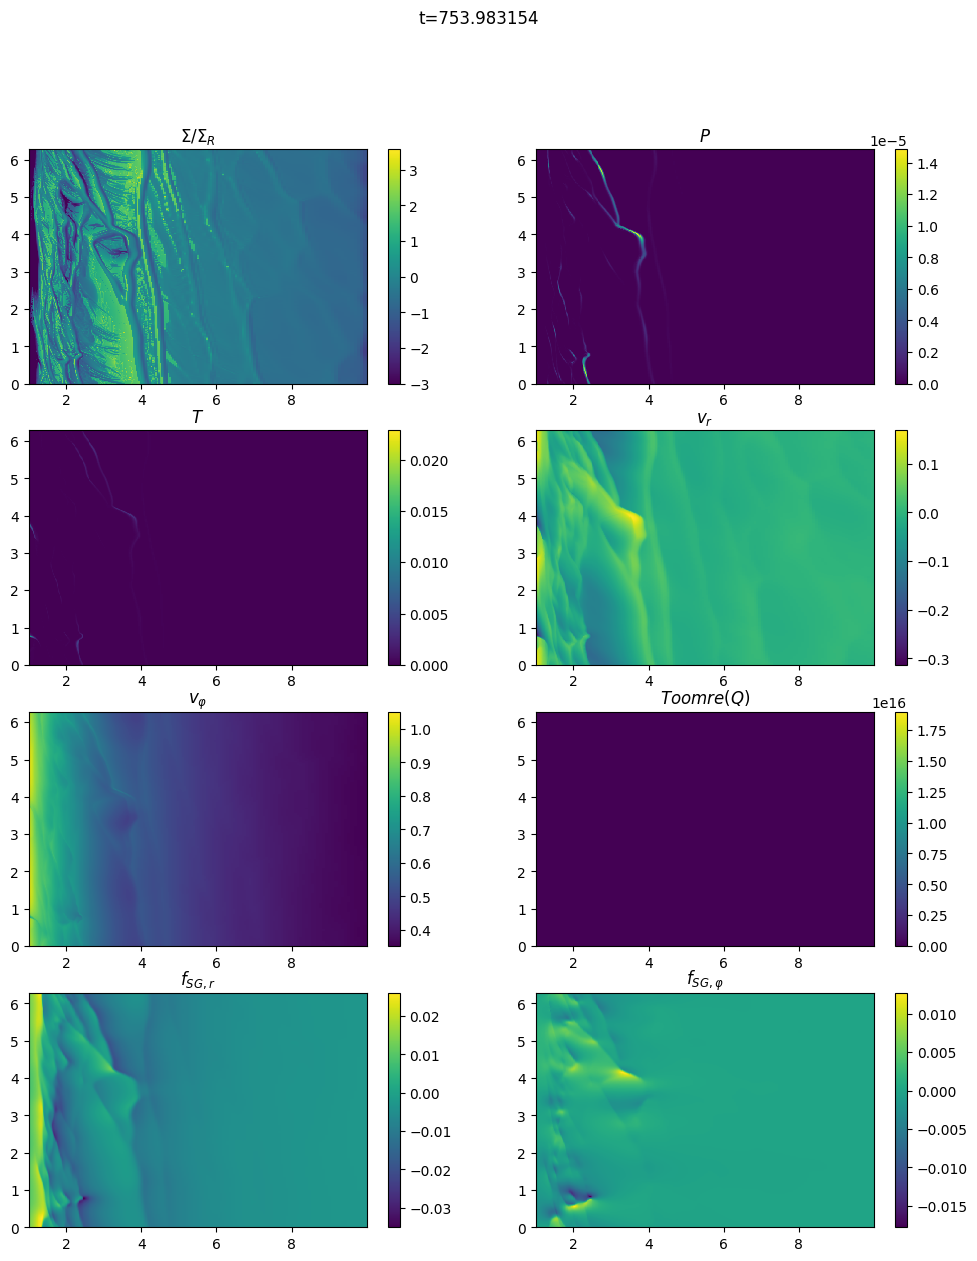

In [6]:
# Load the last VTK file produced by Idefix
V=readVTK("data.0120.vtk")

Temp =  V.data['PRS'][:,:,0].T/V.data['RHO'][:,:,0].T
c_sqr = V.data['PRS'][:,:,0]/V.data['RHO'][:,:,0]
H = np.sqrt(c_sqr)/omega_k.T

sigma_R = 7 * c_sqr / H # Roche density

fig, ax      = plt.subplots(4,2, figsize=(12,14))

ax_rho = ax[0][0].pcolormesh(r, phi, np.log(V.data['RHO'][:,:,0].T/sigma_R.T)/np.log(10), vmin=-3)
ax_prs = ax[0][1].pcolormesh(r, phi, V.data['PRS'][:,:,0].T)
ax_temp = ax[1][0].pcolormesh(r, phi, Temp)
ax_vx1 = ax[1][1].pcolormesh(r, phi, V.data['VX1'][:,:,0].T)
ax_vx2 = ax[2][0].pcolormesh(r, phi, V.data['VX2'][:,:,0].T)
ax_Q = ax[2][1].pcolormesh(r, phi, V.data['toomre'][:,:,0].T)
ax_fx = ax[3][0].pcolormesh(r, phi, V.data['forceSGx'][:,:,0].T)
ax_fy = ax[3][1].pcolormesh(r, phi, V.data['forceSGy'][:,:,0].T)

fig.suptitle("t=%f"%V.t[0])

plt.colorbar(ax_rho, ax=ax[0,0])
plt.colorbar(ax_prs, ax=ax[0,1])
plt.colorbar(ax_temp, ax=ax[1,0])
plt.colorbar(ax_vx1, ax=ax[1,1])
plt.colorbar(ax_vx2, ax=ax[2,0])
plt.colorbar(ax_Q, ax=ax[2,1])
plt.colorbar(ax_fx, ax=ax[3,0])
plt.colorbar(ax_fy, ax=ax[3,1])

ax[0][0].set_title(r'$\Sigma/\Sigma_R$')
ax[0][1].set_title(r'$P$')
ax[1][0].set_title(r'$T$')
ax[1][1].set_title(r'$v_r$')
ax[2][0].set_title(r'$v_\varphi$')
ax[2][1].set_title(r'$Toomre (Q)$')
ax[3][0].set_title(r'$f_{SG,r}$')
ax[3][1].set_title(r'$f_{SG,\varphi}$')

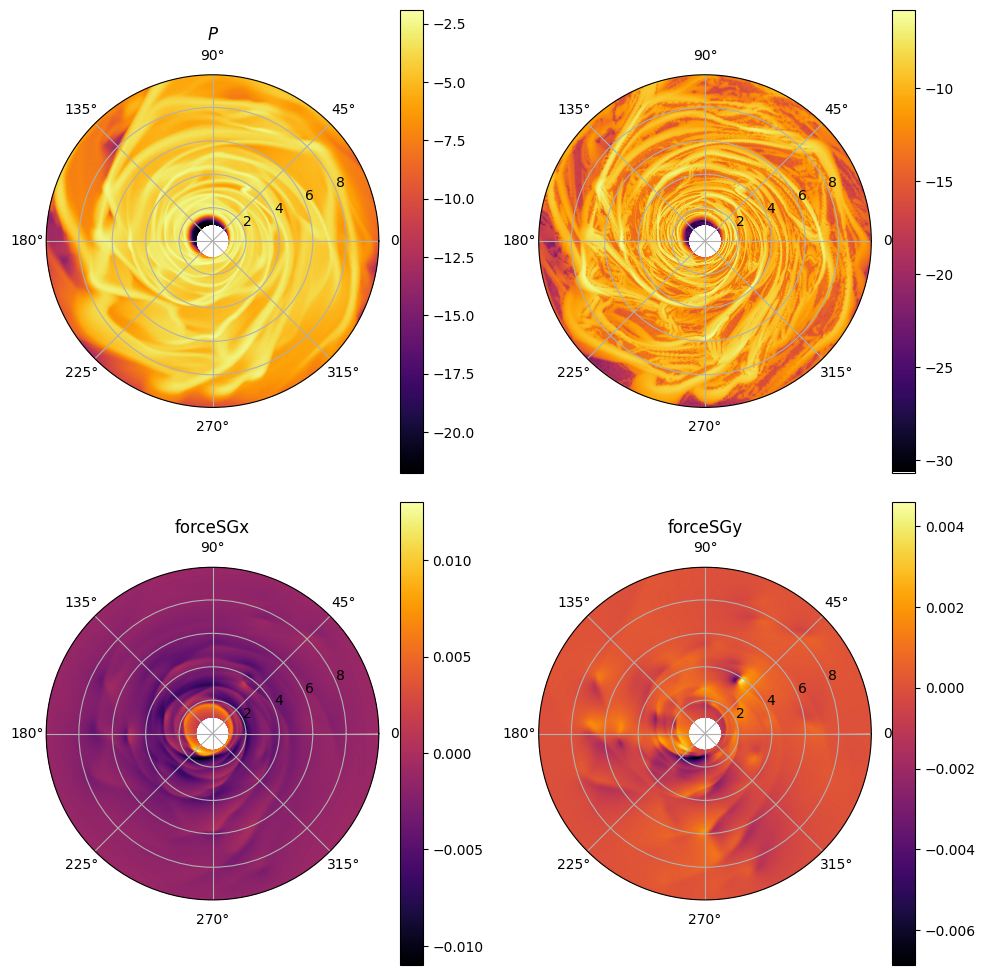

In [7]:
V=readVTK("data.0180.vtk")

rho = V.data['RHO'][:,:,0]
prs = V.data['PRS'][:,:,0]

fig, ax      = plt.subplots(2,2, figsize=(10,10), subplot_kw={'projection': 'polar'})

cs_rho=ax[0,0].pcolormesh(phi, r, np.log10(rho), cmap='inferno', shading='gouraud', alpha=1, snap=True)
cs_prs=ax[0,1].pcolormesh(phi, r, np.log10(prs), cmap='inferno', shading='gouraud', alpha=1, snap=True)
cs_fx=ax[1,0].pcolormesh(V.y, V.x, V.data['forceSGx'][:,:,0], cmap='inferno', shading='gouraud', alpha=1, snap=True)
cs_fy=ax[1,1].pcolormesh(V.y, V.x, V.data['forceSGy'][:,:,0], cmap='inferno', shading='gouraud', alpha=1, snap=True)


ax[0,0].set_title(r'$\Sigma$')
ax[0,0].set_title(r'$P$')
ax[1,0].set_title('forceSGx')
ax[1,1].set_title('forceSGy')

plt.colorbar(cs_rho, ax=ax[0,0])
plt.colorbar(cs_prs, ax=ax[0,1])
plt.colorbar(cs_fx, ax=ax[1,0])
plt.colorbar(cs_fy, ax=ax[1,1])

fig.tight_layout()

#fig.savefig('fig_title.png', dpi=200, bbox_inches='tight')